# 13 - Stacking Classifier

Instead of simply averaging predictions (voting), stacking trains a **meta model** that learns how to best combine the base models' outputs - potentially learning, for example, "trust XGBoost more when it disagrees with Logistic Regression" rather than treating every base model equally.

Uses the same top performing models selected in Notebook 12, with a Logistic Regression meta learner (simple and interpretable, consistent with why we chose Logistic Regression as our baseline model in the first place).


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Select the same top performing base models as the Voting Classifier

In [2]:
import json
import pandas as pd
from pathlib import Path

eligible_metrics_files = {
    'Logistic Regression': '../../../data/processed/metrics_logreg.json',
    'SVM (Linear)': '../../../data/processed/metrics_svm.json',
    'AdaBoost': '../../../data/processed/metrics_adaboost.json',
    'Gradient Boosting': '../../../data/processed/metrics_gb.json',
    'Random Forest': '../../../data/processed/metrics_rf.json',
    'XGBoost': '../../../data/processed/metrics_xgb.json',
    'LightGBM': '../../../data/processed/metrics_lightgbm.json',
    'CatBoost': '../../../data/processed/metrics_catboost.json',
}

ranked = []
for name, path in eligible_metrics_files.items():
    with open(path) as f:
        m = json.load(f)
    ranked.append(m)

ranked_df = pd.DataFrame(ranked).set_index('model').sort_values('recall', ascending=False)
print("Eligible models ranked by validation Recall:")
print(ranked_df[['recall', 'precision', 'f1', 'roc_auc']])

TOP_N = 4
top_models = ranked_df.head(TOP_N).index.tolist()
print(f"\nSelected top {TOP_N} models for the ensemble: {top_models}")


Eligible models ranked by validation Recall:
                               recall  precision        f1   roc_auc
model                                                               
Random Forest                0.617200   0.792379  0.693904  0.758014
XGBoost                      0.606216   0.815980  0.695629  0.759467
LightGBM                     0.601075   0.823567  0.694947  0.764321
CatBoost                     0.593597   0.835801  0.694179  0.764244
Gradient Boosting (sklearn)  0.591727   0.840917  0.694650  0.763873
AdaBoost                     0.569526   0.836307  0.677603  0.739317
SVM (Linear)                 0.561814   0.839385  0.673107  0.739186
Logistic Regression          0.554335   0.837866  0.667229  0.739404

Selected top 4 models for the ensemble: ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


## 2. Build and train the Stacking Classifier

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

model_builders = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, random_state=42),
    'SVM (Linear)': lambda: CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42), cv=3),
    'AdaBoost': lambda: AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    'Gradient Boosting': lambda: GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lambda: LGBMClassifier(n_estimators=200, max_depth=-1, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': lambda: CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False),
}

estimators = [(name.lower().replace(' ', '_').replace('(', '').replace(')', ''), model_builders[name]())
              for name in top_models]
print(f"Built {len(estimators)} fresh estimator instances for ensembling: {[e[0] for e in estimators]}")


Built 4 fresh estimator instances for ensembling: ['random_forest', 'xgboost', 'lightgbm', 'catboost']


In [5]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)

y_pred = stacking_clf.predict(X_val)
y_score = stacking_clf.predict_proba(X_val)[:, 1]


## 3. Evaluate on the validation set

In [6]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()
    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Stacking Classifier (validation set) ---
  recall: 0.5973
  precision: 0.8299
  f1: 0.6947
  roc_auc: 0.7641
  pr_auc: 0.8288

              precision    recall  f1-score   support

 On time (0)       0.64      0.85      0.73      3611
    Late (1)       0.83      0.60      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.71      7890
weighted avg       0.74      0.72      0.71      7890



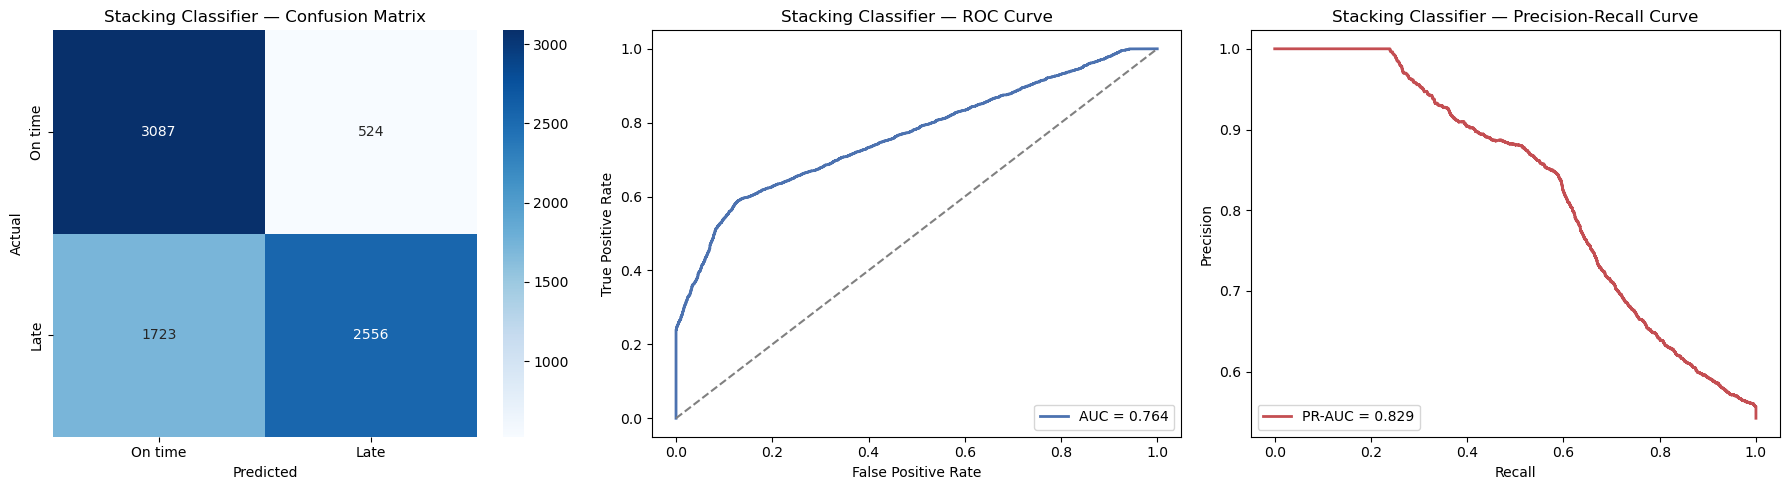

In [7]:
stacking_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Stacking Classifier', save_prefix='stacking')


**What we found: essentially the same outcome as the Voting Classifier, confirming the problem isn't the combination method, it's the lack of diversity among the 4 base models.**

| Metric | Random Forest (best individual) | Voting Classifier | Stacking Classifier |
|---|---|---|---|
| Recall | **0.6172** | 0.5966 | 0.5973 |
| Precision | 0.7924 | 0.8321 | 0.8299 |
| F1 | 0.6939 | 0.6950 | 0.6947 |
| ROC-AUC | 0.7580 | 0.7616 | 0.7641 |
| PR-AUC | 0.8234 | 0.8276 | 0.8288 |

Stacking and Voting land within a hair of each other on every metric, both show the same pattern: a real Recall drop versus Random Forest alone (about 2 points for both), with marginal gains on F1/ROC-AUC/PR-AUC. **Giving the ensemble a smarter, learned combination method instead of simple averaging didn't fix the core problem, because the core problem was never the combination method.** It was that all 4 base models are tree/boosting ensembles trained on the same features, so a meta-learner has no genuinely different perspectives to combine, it can only reweight variations on the same underlying signal.

**This is a stronger, more complete finding than either ensemble notebook alone could show**: both Voting and Stacking independently arrive at "worse Recall than Random Forest alone," which is much better evidence that this is a real property of the model selection (lack of diversity) than either result would be on its own.


## 4. Inspect the meta learner's weights 

In [9]:
meta_coef_df = pd.DataFrame({
    'base_model': [name for name, _ in estimators],
    'meta_weight': stacking_clf.final_estimator_.coef_[0]
}).sort_values('meta_weight', ascending=False)

print("How much the meta learner trusts each base model:")
meta_coef_df


How much the meta learner trusts each base model:


,base_model,meta_weight
3,catboost,3.803476
2,lightgbm,0.950891
0,random_forest,0.633188
1,xgboost,-0.128762


**What we found, and it explains exactly why the Recall drop happened:**

| Base model | Meta-learner weight |
|---|---|
| CatBoost | **3.80** (dominant) |
| LightGBM | 0.95 |
| Random Forest | 0.63 |
| XGBoost | -0.13 (slightly negative) |

**The meta learner heavily favors CatBoost, and assigns XGBoost a slightly *negative* weight**, meaning when XGBoost's prediction disagrees with the consensus, the meta learner leans against it rather than toward it. This is a genuinely revealing result: Random Forest, the model with the best individual Recall (0.6172), gets a comparatively modest weight (0.63), well below CatBoost's 3.80, even though CatBoost individually had the *lowest* Recall of the four base models (0.5936).

**Why this happens:** the meta learner (a plain Logistic Regression) is trained to minimize its own default loss (log loss) on the out of fold predictions, it has no built in awareness that Recall is *our* business priority. It's optimizing for whichever combination best predicts the label overall, which naturally favors the base models with the best calibrated, most confident probability outputs (CatBoost and LightGBM tend to produce well calibrated probabilities), not necessarily the one that's best at the specific metric we actually care about.

**note:** if the group wants an ensemble that actually reflects the Recall priority, the default stacking setup isn't the way to get it, the meta learner's implicit objective needs to be aligned with Recall specifically (for example, by scoring the meta-learner's cross-validation with a Recall-focused metric instead of the default, or by tuning the final decision threshold on the stacked output rather than trusting the meta-learner's own weighting to reflect our priorities). Worth stating this explicitly in the report: it's a limitation of the tool's default behavior, not evidence that stacking can't work here.


## 5. Save model and metrics

In [10]:
joblib.dump(stacking_clf, '../../../models/stacking_classifier.pkl')
save_metrics(stacking_metrics, '../../../data/processed/metrics_stacking.json')


Saved metrics to ../../../data/processed/metrics_stacking.json
